## Split Data into Train and Test Sets

In [2]:
%load_ext autoreload
%autoreload 2

Import libraries

In [3]:
import sys
from pathlib import Path
project_root = Path.resolve(Path.cwd() / '../..')
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))

Read data from Azure Data Lake Storage (ADLS).

In [4]:
from azure.identity import ClientSecretCredential
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
load_dotenv('../../.datalake_sp_creds.env')
import os

credential = ClientSecretCredential(
    tenant_id=os.getenv("DATALAKE_TENANT_ID"),
    client_id=os.getenv("DATALAKE_CLIENT_ID"),
    client_secret=os.getenv("DATALAKE_CLIENT_SECRET")
)

blob_service_client = BlobServiceClient(
    account_url=f"https://{os.getenv("DATALAKE_ACCOUNT_NAME")}.blob.core.windows.net",
    credential=credential
)

container_name = "raw"
delta_path = "delta/gold/production_time"

blob_client = blob_service_client.get_blob_client(container=container_name, blob=delta_path)
if blob_client.exists():
    print(f"Blob '{delta_path}' exists in container '{container_name}'.")

Blob 'delta/gold/production_time' exists in container 'raw'.



---
### 1. Read data from ADLS

I'm using DuckDB with the Delta Lake extension to read the Delta table directly from ADLS, ensuring that deletion vectors are respected. Data was created with Databricks, which uses Delta Lake format with deletion vectors for handling deletes and updates.

> `NOTE` deltalake Python library does not support deletion vectors,<br/>so using DuckDB is necessary to get the correct data splits).

In [5]:
import os
import duckdb

DATALAKE_ACCOUNT_NAME = os.getenv("DATALAKE_ACCOUNT_NAME")
TENANT_ID = os.getenv("DATALAKE_TENANT_ID")
CLIENT_ID = os.getenv("DATALAKE_CLIENT_ID")
CLIENT_SECRET = os.getenv("DATALAKE_CLIENT_SECRET")

# Initialize DuckDB
con = duckdb.connect()

# Load required extensions
con.execute("INSTALL azure; LOAD azure;")
con.execute("INSTALL delta; LOAD delta;")

# Create a formal Azure Secret object using Service Principal credentials
# (This isolates the account name mapping so delta_scan understands the protocol)
con.execute(f"""
    CREATE SECRET azure_sp (
        TYPE AZURE,
        PROVIDER SERVICE_PRINCIPAL,
        TENANT_ID '{TENANT_ID}',
        CLIENT_ID '{CLIENT_ID}',
        CLIENT_SECRET '{CLIENT_SECRET}',
        ACCOUNT_NAME '{DATALAKE_ACCOUNT_NAME}'
    );
""")

# Use the specific 'az://' URI scheme expected by delta_scan
container_name = "raw"
delta_path = "delta/gold/production_time"
azure_uri = f"az://{container_name}/{delta_path}"

try:
    # Extract and parse directly to your Pandas Dataframe
    df_gold = (
        con.execute(f"SELECT * FROM delta_scan('{azure_uri}')")
        .df()
        .drop(columns=['transformation_timestamp', 'source_file'])
    )
    
    print("DataFrame successfully loaded via DuckDB with Deletion Vectors supported!")
except Exception as e:
    print(f"Failed to read Delta table: {e}")


DataFrame successfully loaded via DuckDB with Deletion Vectors supported!


Display the first few rows and data types to verify successful loading.

In [6]:
import pandas as pd
from IPython.display import display

display(df_gold.head())
display(pd.DataFrame(df_gold.dtypes, columns=['Data Type']).T)

,op_w,op_l,wire_dia,mesh_fl,mesh_sp,batch_width,batch_length,process_time,qty,op_align,stand_type
0,50.0,50.0,9.0,860.0,1500.0,860.0,2000.0,40.0,1,S,B
1,70.0,70.0,12.0,1450.0,1760.0,1450.0,4100.0,80.0,2,S,B
2,25.0,25.0,5.5,1220.0,2350.0,1220.0,3000.0,60.0,1,S,B
3,10.0,10.0,3.0,1520.0,1800.0,1520.0,4200.0,85.0,2,S,B
4,10.0,10.0,3.0,995.0,2100.0,995.0,2700.0,45.0,1,S,B


,op_w,op_l,wire_dia,mesh_fl,mesh_sp,batch_width,batch_length,process_time,qty,op_align,stand_type
Data Type,float32,float32,float32,float32,float32,float32,float32,float32,int32,object,object



---
### 2. Data splitting
- split cleaned data into training and testing sets 80/20
- use random state for reproducibility
- extract target variable: `process_time` for regression

In [7]:
from sklearn.model_selection import train_test_split

random_state = 42
test_size = 0.2

X = df_gold.drop(columns=['process_time'])
y = df_gold['process_time']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=test_size, 
    random_state=random_state
)

#### Data Leakage Checks

Leakage check: check for duplicate rows between training and testing sets to ensure no data leakage.

In [8]:
import numpy as np

train_hash = pd.util.hash_pandas_object(X_train)
test_hash = pd.util.hash_pandas_object(X_test)

overlap = np.intersect1d(train_hash.values, test_hash.values)

print(len(overlap))

0



---
### 3. Distribution Stability Across Data Splits

Plot histograms of numeric features in training and testing sets to visually inspect distribution stability across splits.

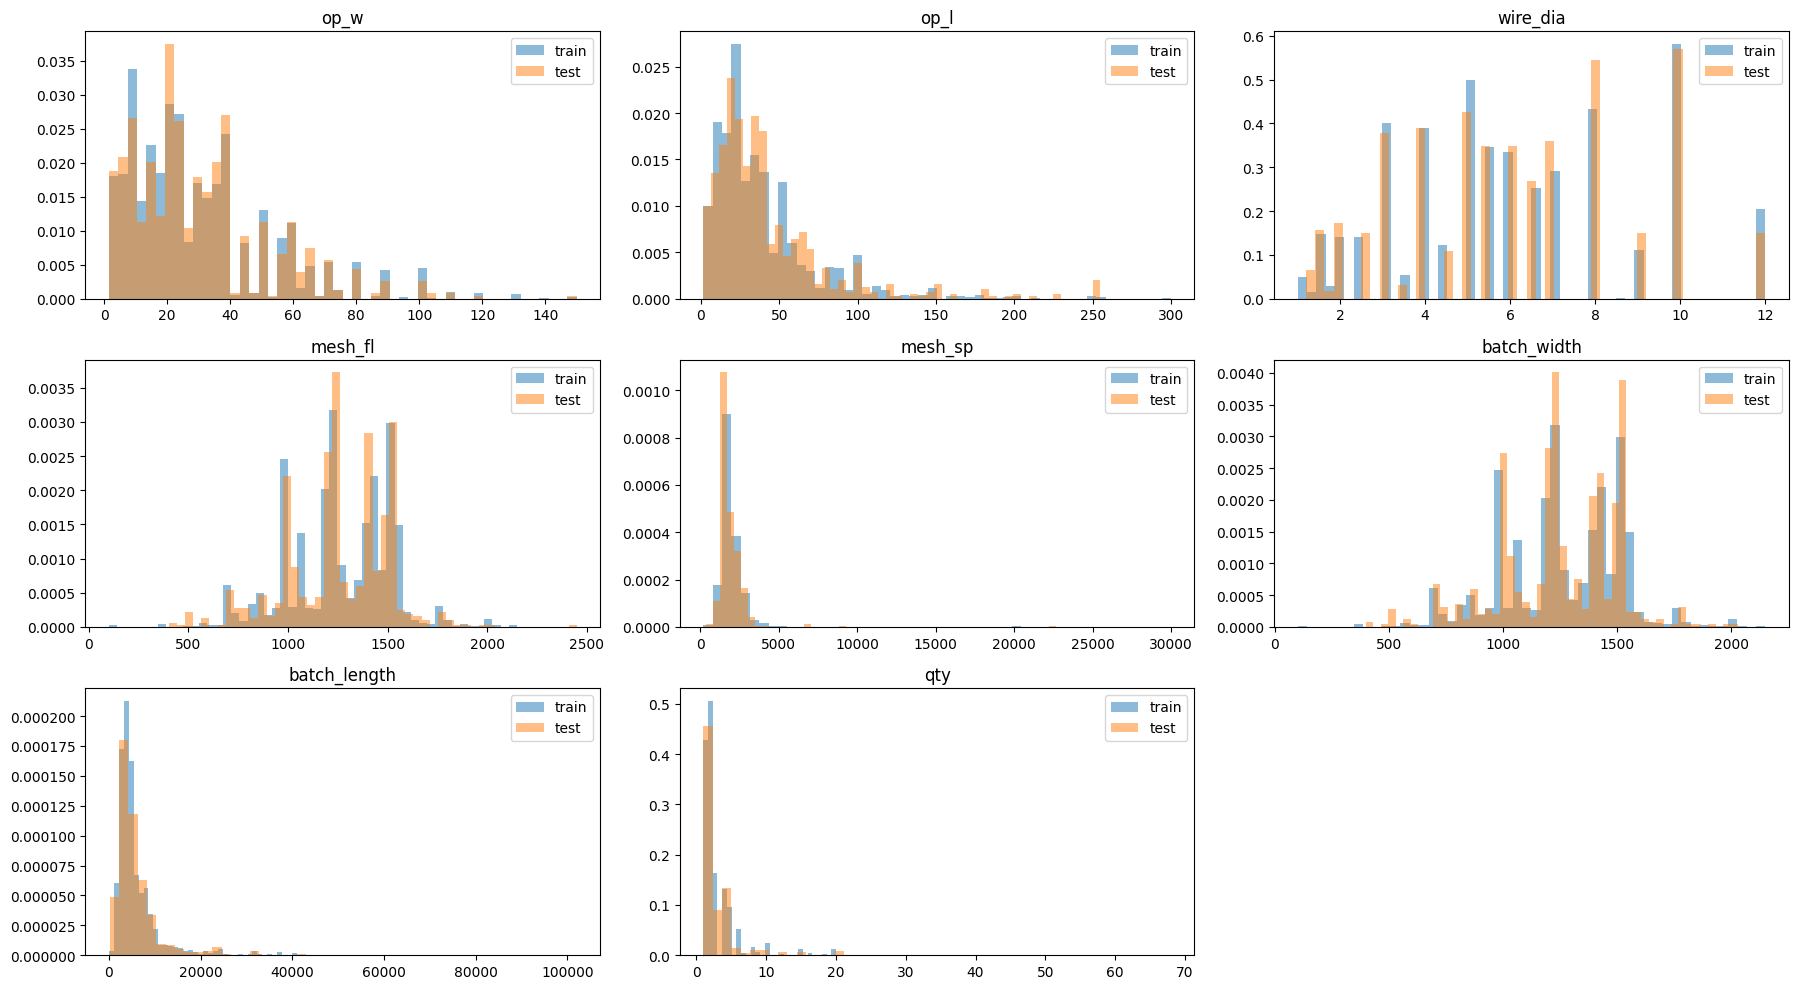

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
numeric_features = X_train.select_dtypes(include='number').columns
categorical_features = X_train.select_dtypes(include='object').columns
for i, feature in enumerate(numeric_features):
    plt.subplot(3, 3, i + 1)
    plt.hist(X_train[feature], bins=50, alpha=0.5, density=True, label="train")
    plt.hist(X_test[feature], bins=50, alpha=0.5, density=True, label="test")
    plt.title(feature)
    plt.legend()
plt.tight_layout()
plt.show()

Data distribution plots shows significant multimodality in features, which indicates that there are likely distinct subpopulations or clusters within the data. The production is of type High-Variance Low-Volume, which means that there are likely different types of production runs (e.g., small batches vs large batches) that have very different characteristics and various product families due to broad range of opening sizes across different batches. This multimodality can pose challenges for modeling, as the model may struggle to capture the underlying patterns in the data if it is not able to account for these distinct subpopulations.

However, these distributions shows something very significant - the distributions are very similar between the training and testing sets, which is a good sign that the data splitting process has maintained the underlying structure of the data and that the data itself holds consistent patterns that can be learned by a model. This resolves my major concern about quality of dataset, which was collected over 10 years ago with not much attention to data quality, and gives me confidence that we can build a model that generalizes well to unseen data.

Summary stats drift check: compare summary statistics of features in training and testing sets to identify any significant differences that could indicate drift.

In [10]:
from IPython.display import Markdown
feature = "batch_length"

summary = pd.DataFrame({
    "train": X_train[feature].describe().round(2),
    "test": X_test[feature].describe().round(2)
})

display(Markdown(f"### Example summary statistics for feature: `{feature}`"))
display(summary)

### Example summary statistics for feature: `batch_length`

,train,test
count,3089.00,773.00
mean,6077.16,6247.32
std,5587.95,6691.07
min,6.80,200.00
25%,3200.00,3200.00
50%,4500.00,4500.00
75%,6600.00,6800.00
max,54000.00,102000.00


#### KS statistic check
For the sake of rigor, I perform Kolmogorov-Smirnov (KS) test to compare the distributions of numeric features in training and testing sets. The KS test is a non-parametric test that compares the cumulative distributions of two samples and provides a KS statistic and a p-value to assess whether the distributions are significantly different.

Result interpretation: 
* if p-value < 0.05, reject null hypothesis of same distribution, indicating potential drift or leakage.
* if p-value >= 0.05, fail to reject null hypothesis, indicating no significant difference between distributions.
* if KS statistic is close to 0, distributions are similar; if close to 1, distributions are different.

In [11]:
from scipy.stats import ks_2samp

ks_stats = {}
for feature in numeric_features:
    stat, p = ks_2samp(
        X_train[feature].dropna(),
        X_test[feature].dropna()
    )
    ks_stats[feature] = {"ks_stat": stat, "p_value": p}

df_stats = pd.DataFrame(ks_stats)#.round(4)
display(Markdown("### KS Test Results for Numeric Features"))
display(df_stats)

if any(df_stats.loc['p_value'] < 0.05):
    features_with_drift = df_stats[df_stats['p_value'] < 0.05].index.tolist()
    print("Warning: Significant distribution differences detected\n"
          "between train and test sets for the following features (p < 0.05):")
    for feature in features_with_drift:
        print(f"- {feature} (KS statistic: {df_stats.loc['ks_stat', feature]}, "
              f"p-value: {df_stats.loc['p_value', feature]})")
else:
    print("KS test results indicate no significant distribution differences\n"
          "between train and test sets for numeric features (p >= 0.05).")
    

### KS Test Results for Numeric Features

,op_w,op_l,wire_dia,mesh_fl,mesh_sp,batch_width,batch_length,qty
ks_stat,0.048542,0.046512,0.029282,0.029057,0.042540,0.028084,0.018875,0.024549
p_value,0.104379,0.132772,0.650795,0.659883,0.206085,0.700516,0.976778,0.838925


KS test results indicate no significant distribution differences
between train and test sets for numeric features (p >= 0.05).


While KS test provides a view on distributional differences, it is beneficial to perform additional Population Stability Index (PSI) analysis on categorical features, cause KS test is not suitable for categorical data.

##### PSI (Population Stability Index) check - Model monitoring / ML system
PSI quantifies the magnitude of distributional differences and can provide insights into stability of categorical features across splits. While it it's most common use case is monitoring data drift in production, it can also be applied to training/testing splits to ensure that the splits are representative of each other and that there are no significant distributional differences that could impact model performance.

Result interpretation:
* PSI < 0.1: no significant change in distribution
* 0.1 <= PSI < 0.2: moderate change in distribution, may require monitoring
* PSI >= 0.2: significant change in distribution, potential data drift or leakage, may require investigation and remediation.

In [12]:
import numpy as np

def calculate_psi(expected, actual, bins=10, is_categorical=False):
    # remove missing values
    expected = expected.dropna()
    actual = actual.dropna()
    
    if is_categorical:
        # for categorical data, bins = unique values
        all_categories = list(set(expected).union(set(actual)))
        expected_counts = expected.value_counts().reindex(all_categories, fill_value=0).values
        actual_counts = actual.value_counts().reindex(all_categories, fill_value=0).values
    else:
        # for numerical data, use standard histogram
        expected_counts, bin_edges = np.histogram(expected, bins=bins)
        actual_counts, _ = np.histogram(actual, bins=bin_edges)
        
    expected_percents = expected_counts / len(expected)
    actual_percents = actual_counts / len(actual)
    
    # substitute 0s with a small value to avoid division by zero or log of zero
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    
    # psi formula: sum((actual - expected) * log(actual / expected))
    psi_value = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi_value

# calculate PSI for all features
psi_scores = {}
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

for feature in numeric_features.append(categorical_features):
    psi_scores[feature] = calculate_psi(
        X_train[feature], X_test[feature],
        bins=10, is_categorical=feature in categorical_features
    )

In [13]:
psi_results = { 'moderate': [], 'high': [] }

for feature, score in psi_scores.items():
    if 0.1 < score <= 0.25:
        psi_results['moderate'].append(feature)
    elif score > 0.25:
        psi_results['high'].append(feature)

if any(psi_results['moderate']):
    print("\nFeatures with moderate distribution shift (PSI > 0.1 and <= 0.25):")
    for feature in psi_results['moderate']:
        print(f"- {feature} (PSI: {psi_scores[feature]:.4f})")
if any(psi_results['high']):
    print("\nFeatures with high distribution shift (PSI > 0.25):")
    for feature in psi_results['high']:
        print(f"- {feature} (PSI: {psi_scores[feature]:.4f})")
if not any(psi_results['moderate'] + psi_results['high']):
    print("\nNo features with significant distribution shift detected (PSI <= 0.1).")


No features with significant distribution shift detected (PSI <= 0.1).


#### Target variable distribution
Plots to visualize target variable distribution after splitting. This helps ensure that the distribution of the target variable is similar in both training and testing sets.

C:\Users\singl\AppData\Local\Temp\ipykernel_75728\1251828569.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot([y_train, y_test], labels=['train', 'test'])


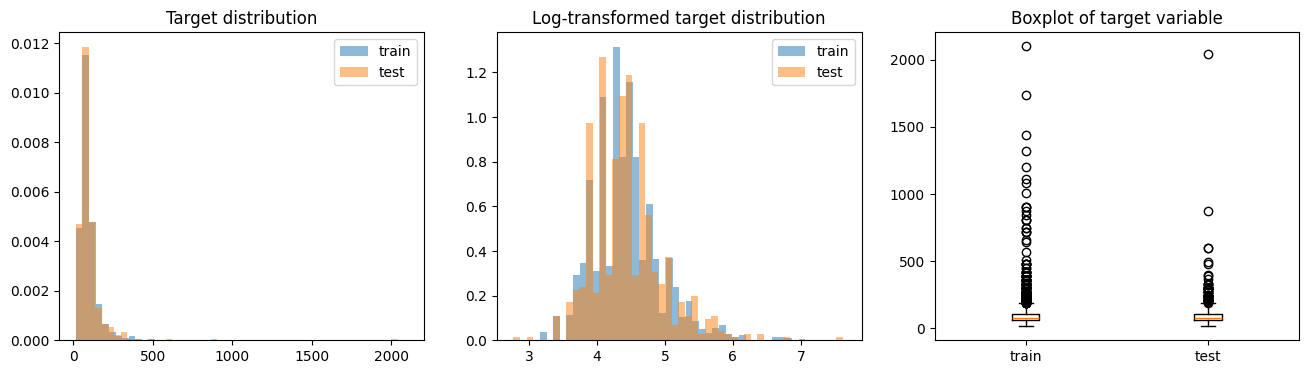

In [14]:
import matplotlib.pyplot as plt
import numpy as np

bins=50

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

# histogram to visualize target variable distribution
ax1.hist(y_train, bins=bins, alpha=0.5, label='train', density=True)
ax1.hist(y_test, bins=bins, alpha=0.5, label='test', density=True)
ax1.legend()
ax1.set_title("Target distribution")

# histogram of log-transformed target variable
ax2.hist(np.log1p(y_train), bins=bins, alpha=0.5, label='train', density=True)
ax2.hist(np.log1p(y_test), bins=bins, alpha=0.5, label='test', density=True)
ax2.legend()
ax2.set_title("Log-transformed target distribution")

# boxplot to visualize difference in distribution and outliers in target variable
ax3.boxplot([y_train, y_test], labels=['train', 'test'])
ax3.set_title("Boxplot of target variable")

plt.show()

Target variable distribution plots shows that the target variable `process_time` has a highly skewed distribution with a long tail, which is common in production data where most runs have short processing times but there are some runs with very long processing times. Both training and testing sets show similar skewed distributions and mainly evenly distributed across different ranges of processing times.

#### Plot Correlation Matrix

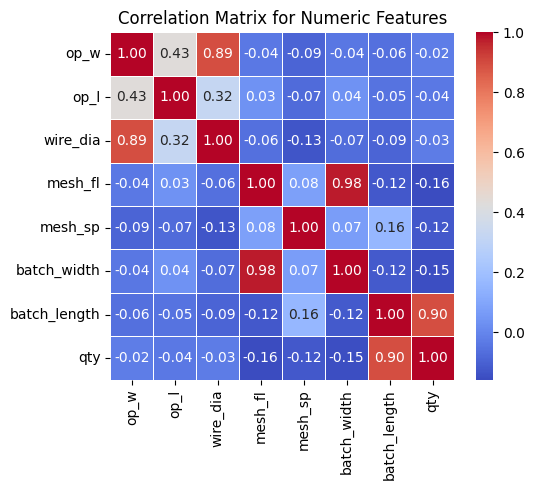

In [16]:
import pandas as pd
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import seaborn as sns

# Corr matrix for numeric features
plt.figure(figsize=(5.6, 5))
numeric_features = X_train.select_dtypes(include='number').columns
categorical_features = X_train.select_dtypes(include='object').columns

corr_matrix = X_train[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix for Numeric Features")
plt.tight_layout()
plt.show()

Correlation matrix shows that very few features have strong correlation with the target variable, which indicates that this is a challenging modeling problem and that we may need to consider feature engineering or more complex models to capture the underlying patterns in the data. Additionally, there are some features that are highly correlated with each other, which could lead to multicollinearity issues in linear models, while most of the features are not strongly correlated with each other nor with the target variable.


---
### 3. Write split data for downstream use

In [20]:
display(X_train.dtypes)

op_w            float32
op_l            float32
wire_dia        float32
mesh_fl         float32
mesh_sp         float32
batch_width     float32
batch_length    float32
qty               int32
op_align         object
stand_type       object
dtype: object

In [14]:
import os; os.makedirs('../../data/split', exist_ok=True)
X_train.to_parquet('../../data/split/production_time_train.parquet', index=False)
X_test.to_parquet('../../data/split/production_time_test.parquet', index=False)
print("Cleaned data saved to '../../data/split/production_time_train.parquet' and '../../data/split/production_time_test.parquet'")
y_train.to_frame().to_parquet('../../data/split/production_time_train_target.parquet', index=False)
y_test.to_frame().to_parquet('../../data/split/production_time_test_target.parquet', index=False)
print("Target variable saved to '../../data/split/production_time_train_target.parquet' and '../../data/split/production_time_test_target.parquet'")

Cleaned data saved to '../../data/split/production_time_train.parquet' and '../../data/split/production_time_test.parquet'
Target variable saved to '../../data/split/production_time_train_target.parquet' and '../../data/split/production_time_test_target.parquet'


---
---